In [ ]:
# Step 1 — Load and Explore the Dataset
import pandas as pd

# Load the dataset (CSV file)
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

# 1. Show a preview of the data (first 5 rows)
df.head()


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [11]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [12]:
df.duplicated().sum()

np.int64(0)

In [3]:
# 2. Display all info and statistics using sweetviz
import sweetviz
report = sweetviz.analyze(df)
report.show_html('report.html')
print('Sweetviz report has been saved as report.html.')


                                             |          | [  0%]   00:00 -> (? left)

Report report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.
Sweetviz report has been saved as report.html.


## Step 3 — Bivariate Analysis

In this step, we will explore pairwise relationships between variables. We will:
- Examine relationships between numerical features (scatterplots, correlations)
- Explore distributions and differences across categorical groups (boxplots, violinplots)
- Analyze relationships between categorical variables (grouped bar charts / cross-tab heatmaps)

This analysis helps reveal associations, potential predictors for attrition, and multicollinearity issues.


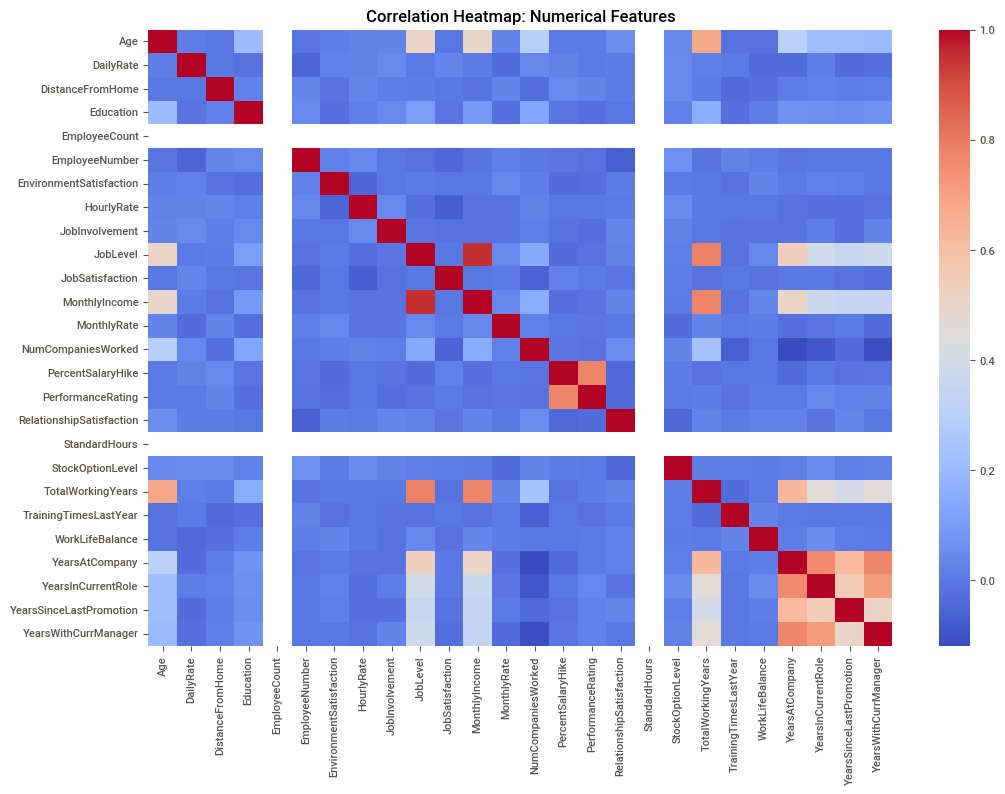

Strong Correlations (|r| > 0.5):
JobLevel                 MonthlyIncome              0.950300
                         TotalWorkingYears          0.782208
PercentSalaryHike        PerformanceRating          0.773550
MonthlyIncome            TotalWorkingYears          0.772893
YearsAtCompany           YearsWithCurrManager       0.769212
                         YearsInCurrentRole         0.758754
YearsInCurrentRole       YearsWithCurrManager       0.714365
Age                      TotalWorkingYears          0.680381
TotalWorkingYears        YearsAtCompany             0.628133
YearsAtCompany           YearsSinceLastPromotion    0.618409
YearsInCurrentRole       YearsSinceLastPromotion    0.548056
JobLevel                 YearsAtCompany             0.534739
MonthlyIncome            YearsAtCompany             0.514285
YearsSinceLastPromotion  YearsWithCurrManager       0.510224
Age                      JobLevel                   0.509604
dtype: float64


In [6]:
# Step 3 — Bivariate Analysis

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns
num_cols = df.select_dtypes(include='number').columns

# Correlation matrix
corr = df[num_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap: Numerical Features')
plt.show()

# Display strong correlations only once
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

strong_corr = (
    upper.stack()
         .loc[lambda x: x.abs() > 0.5]
         .sort_values(key=abs, ascending=False)
)

print('Strong Correlations (|r| > 0.5):')
print(strong_corr)

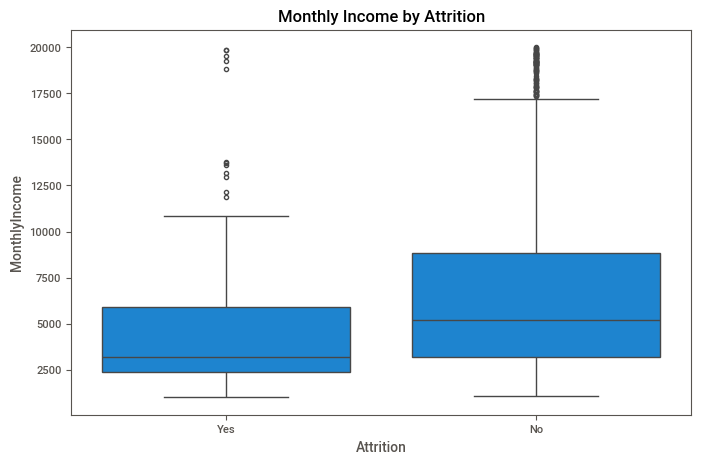

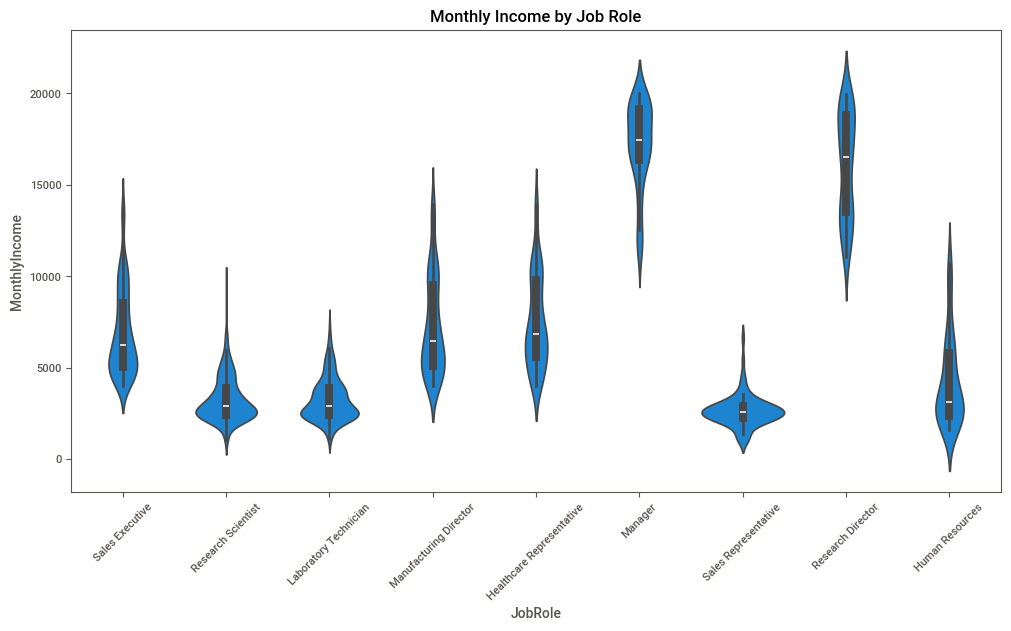

In [7]:
# Bivariate Analysis: Numerical vs Categorical

# Monthly Income by Attrition
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome')
plt.title('Monthly Income by Attrition')
plt.show()

# Monthly Income by Job Role
plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x='JobRole', y='MonthlyIncome')
plt.title('Monthly Income by Job Role')
plt.xticks(rotation=45)
plt.show()

### Insights from Bivariate Analysis

- A very strong positive correlation was observed between `JobLevel` and `MonthlyIncome` (r = 0.95).
- `TotalWorkingYears` showed strong positive correlations with `JobLevel` (r = 0.78) and `MonthlyIncome` (r = 0.77).
- `YearsAtCompany`, `YearsInCurrentRole`, and `YearsWithCurrManager` showed strong positive relationships, indicating overlap among several tenure-related features.
- `PercentSalaryHike` and `PerformanceRating` showed a strong positive correlation (r = 0.77).
- The boxplot and violin plot provide a first look at differences in `MonthlyIncome` across `Attrition` groups and `JobRole` categories.

These relationships will be considered during feature engineering and model development, particularly when addressing potential multicollinearity.

## Step 4 — Feature Engineering

In this step, we will create new features derived from the existing data to enhance potential predictive power for machine learning. Feature engineering can capture hidden patterns, interactions, or nonlinear relationships.


In [8]:
# Step 4 — Feature Engineering

# Tenure as a fraction of employee age
df['TenureFraction'] = df['YearsAtCompany'] / df['Age']

# Log transformation of Monthly Income
df['LogMonthlyIncome'] = np.log1p(df['MonthlyIncome'])

# Encode Overtime as binary
df['OvertimeFlag'] = (df['OverTime'] == 'Yes').astype(int)

# Interaction between Job Level and Job Involvement
df['JobLevelInvolvement'] = df['JobLevel'] * df['JobInvolvement']

print("Feature engineering completed successfully.")
print("New features:", [
    'TenureFraction',
    'LogMonthlyIncome',
    'OvertimeFlag',
    'JobLevelInvolvement'
])

Feature engineering completed successfully.
New features: ['TenureFraction', 'LogMonthlyIncome', 'OvertimeFlag', 'JobLevelInvolvement']


#### Feature Explanations

- `TenureFraction`: Represents years at the company relative to employee age, providing an age-adjusted measure of tenure.

- `LogMonthlyIncome`: Log-transformed version of monthly income to reduce the effect of extreme values and reduce right skewness.

- `OvertimeFlag`: Binary representation of overtime status (1 = Yes, 0 = No), making the categorical feature easier to use in analysis and modeling.

- `JobLevelInvolvement`: Interaction feature combining job level and job involvement to capture potential relationships between the two variables.

## Step 5 — Visualization & Insights

We will summarize key insights visually, using correlation heatmaps, pairplots, and distribution plots for important features. These visualizations highlight the most influential relationships in the data.


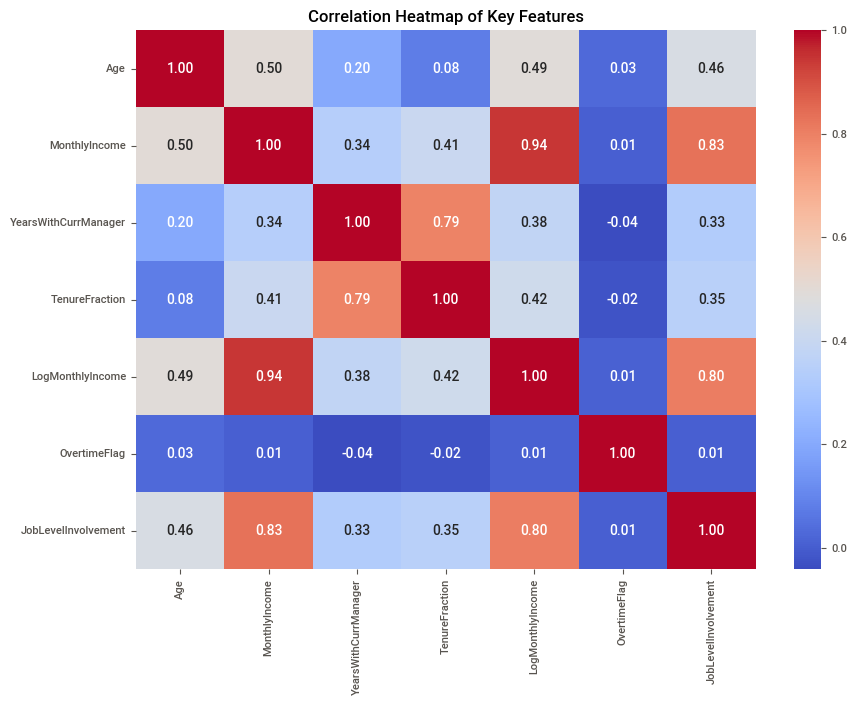

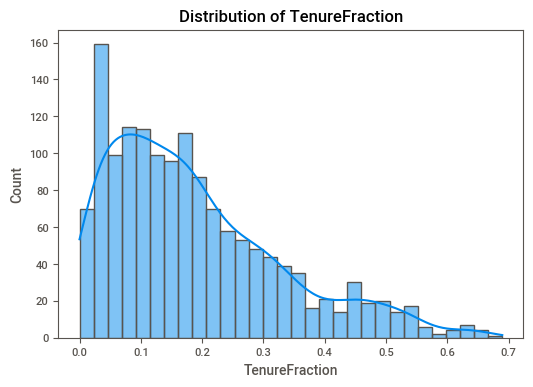

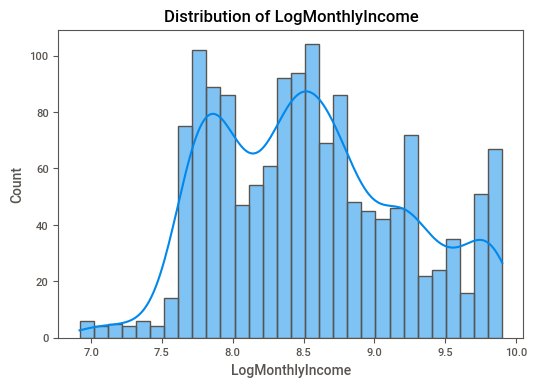

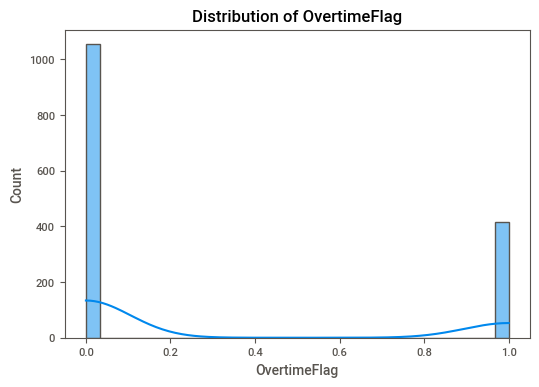

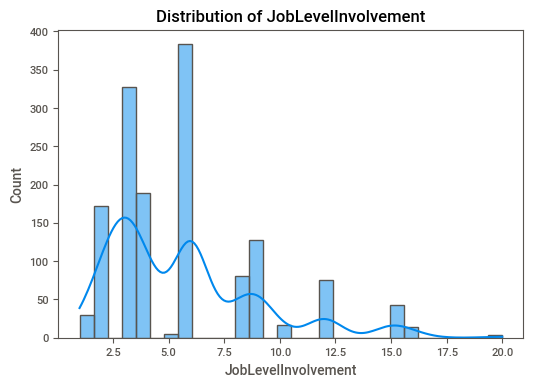

In [9]:
# Step 5 — Visualization & Insights

# Correlation Heatmap of Engineered Features
selected_cols = [
    'Age',
    'MonthlyIncome',
    'YearsWithCurrManager',
    'TenureFraction',
    'LogMonthlyIncome',
    'OvertimeFlag',
    'JobLevelInvolvement'
]

corr = df[selected_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Key Features')
plt.show()

# Distribution of Engineered Features
engineered_cols = [
    'TenureFraction',
    'LogMonthlyIncome',
    'OvertimeFlag',
    'JobLevelInvolvement'
]

for col in engineered_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(data=df, x=col, kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.show()

### Main Findings and Relationships

- The correlation heatmap highlights the relationships between the selected raw and engineered features.
- The distribution plots show the distributions of the engineered features and the effect of the applied transformations.
- Strong correlations among some features indicate potential multicollinearity that should be considered during model development.
- The engineered features will be evaluated later to determine whether they provide additional predictive value for employee attrition.

## Step 6 — Document Findings

Below is a summary of the most important findings, relationships, and business implications from the exploratory data analysis.


###  Class Imbalance Analysis

Before proceeding to modeling, we need to address a critical data quality issue: **class imbalance** in the target variable (`Attrition`).


CLASS DISTRIBUTION ANALYSIS

Absolute counts:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Percentages:
No: 83.88%
Yes: 16.12%


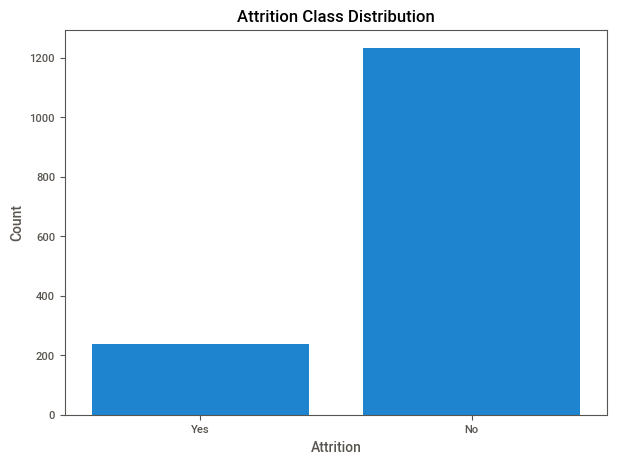


Imbalance Ratio: 5.20:1


In [10]:
# Step 6 — Document Findings
# Class Imbalance Analysis

# Check class distribution in Attrition
value_counts = df['Attrition'].value_counts()
percentages = df['Attrition'].value_counts(normalize=True) * 100

print("=" * 50)
print("CLASS DISTRIBUTION ANALYSIS")
print("=" * 50)

print("\nAbsolute counts:")
print(value_counts)

print("\nPercentages:")
for value, percentage in percentages.items():
    print(f"{value}: {percentage:.2f}%")

# Visualize class distribution
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='Attrition')
plt.title('Attrition Class Distribution')
plt.xlabel('Attrition')
plt.ylabel('Count')
plt.show()

# Calculate imbalance ratio
minority_class = value_counts.min()
majority_class = value_counts.max()
imbalance_ratio = majority_class / minority_class

print(f"\nImbalance Ratio: {imbalance_ratio:.2f}:1")

### EDA Summary Report

#### Key Correlations

- Strong correlations were observed among several numerical features, particularly between `JobLevel` and `MonthlyIncome` (r = 0.95).
- `TotalWorkingYears` was strongly correlated with `JobLevel` (r = 0.78) and `MonthlyIncome` (r = 0.77).
- Several tenure-related features also showed strong correlations, indicating potential multicollinearity.

#### Important Features for Further Investigation

- `MonthlyIncome`, `JobLevel`, `TotalWorkingYears`, `YearsAtCompany`, and `OverTime` showed meaningful relationships that warrant further investigation during modeling.
- The engineered features were created to capture additional patterns, but their predictive value will be evaluated during the machine learning stage.

#### Data Quality and Preparation

- The dataset contains no missing values requiring imputation based on the initial EDA.
- Categorical and numerical features were identified and examined during the exploration process.
- A significant class imbalance was identified in `Attrition`, with `83.88%` of employees classified as `No` and `16.12%` as `Yes`, representing an imbalance ratio of approximately `5.20:1`.

#### Business Insights

- Compensation, job level, tenure, and overtime status are important areas for further investigation when analyzing employee attrition.
- Differences across job roles and other employee characteristics should be evaluated further to identify groups with potentially higher attrition risk.
- The identified relationships provide a foundation for the upcoming machine learning stage, where predictive performance and feature importance will be evaluated.

In [13]:
# Save cleaned dataset
df.to_csv('cleaned_data.csv', index=False)

print('Cleaned dataset saved as cleaned_data.csv')

Cleaned dataset saved as cleaned_data.csv
